<a href="https://colab.research.google.com/github/AryushGupta/AI-ML-Projects/blob/main/E_commerce_Sales_Performance_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Importing the required libraries and downloading the dataset directly from Kaggle***

In [9]:
import pandas as pd
import numpy as np
import os

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinothkannaece/sales-dataset")

print("Path to dataset files:", path)

100%|██████████| 27.0k/27.0k [00:00<00:00, 16.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vinothkannaece/sales-dataset/versions/1


Completing the full path of the file using os module methods

In [11]:
files = os.listdir(path)
print("Files in folder: ", files)

Files in folder:  ['sales_data.csv']


In [12]:
file_name = files[0]
full_path = os.path.join(path , file_name)
df = pd.read_csv(full_path)

In [13]:
print(df.head(5))

   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1           Cash        Re

**Data Cleaning**

In [14]:
# Checking the records with missing values such as NaN, NULL, empty cells
# isnull() methods checks the entire dataframe for such values
print(df.isnull().sum())

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [15]:
# we can also use .info method to check if any column containing null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [16]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [17]:
# checking the duplicate records
duplicate_rec = df[df.duplicated()]
print(f"Duplicate records : {duplicate_rec}")

Duplicate records : Empty DataFrame
Columns: [Product_ID, Sale_Date, Sales_Rep, Region, Sales_Amount, Quantity_Sold, Product_Category, Unit_Cost, Unit_Price, Customer_Type, Discount, Payment_Method, Sales_Channel, Region_and_Sales_Rep]
Index: []


In [18]:
# checking the datatypes of each feature of a dataset
print(df.dtypes)

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object


In [19]:
# finding the mixed data types within each column
# better way to find if a certain column has more than one datatype as 'object' container can catch different data types and label it under 'object'
# In Pandas, object is a catch-all container. A single column with an object dtype can seamlessly hold a native Python string in row 1, an integer in row 2, and a dictionary or floating-point number in row 3.
for col in df.columns:
  unique_types = df[col].apply(type).unique()

  if len(unique_types)>1:
    print(f"Inconsistent column: {col} contains mixed types: {unique_types}")
  else:
    print(f"Consistent column: {col} is strictly {unique_types[0]}")


Consistent column: Product_ID is strictly <class 'int'>
Consistent column: Sale_Date is strictly <class 'str'>
Consistent column: Sales_Rep is strictly <class 'str'>
Consistent column: Region is strictly <class 'str'>
Consistent column: Sales_Amount is strictly <class 'float'>
Consistent column: Quantity_Sold is strictly <class 'int'>
Consistent column: Product_Category is strictly <class 'str'>
Consistent column: Unit_Cost is strictly <class 'float'>
Consistent column: Unit_Price is strictly <class 'float'>
Consistent column: Customer_Type is strictly <class 'str'>
Consistent column: Discount is strictly <class 'float'>
Consistent column: Payment_Method is strictly <class 'str'>
Consistent column: Sales_Channel is strictly <class 'str'>
Consistent column: Region_and_Sales_Rep is strictly <class 'str'>


In [20]:
#checking the date format for each record if it is consistent or not
from datetime import datetime

def check_Date_format(date_string, expected_format):
  try:
    datetime.strptime(date_string, expected_format)
    return True
  except ValueError:
    return False

format_code = "%Y-%m-%d"

all_sale_date = df["Sale_Date"]

for sale_date in all_sale_date:
  if check_Date_format(sale_date, format_code):
    continue
  else:
    print("Error in date format")
    break


In [21]:
# better way of checking the date format , returns the product id with wrong date format
date_format_incorrect = 0
for id, date in zip(df["Product_ID"],df["Sale_Date"]):
  if not check_Date_format(date, format_code):
    print(f"Format of : {date} at Product ID : {id} is wrong.")
    date_format_incorrect = 1
    break

if not date_format_incorrect:
  print("All Date formats are correct")

All Date formats are correct


In [22]:
# Checking the regions which should include only North , South , East , West
all_regions_data = df["Region"]
directions = {"North","South","East","West"}

incorrect_region = 0
for id, region in zip(df["Product_ID"], df["Region"]):
  if region not in directions:
    print(f"Product Id : {id} {region} is incorrect.")
    incorrect_region = 1
    break

if not incorrect_region:
  print("All sales region are correct.")

All sales region are correct.


In [23]:
# Checking the Sales numbers as they should be within the range of 100 to 10000
sales_number_flag = 0

for id, saleAmt in zip(df["Product_ID"], df["Sales_Amount"]):
  if saleAmt < 100 or saleAmt > 10000:
    sales_number_flag = 1
    print(f"Product Id : {id} with Total Sale Amount is {saleAmt} is incorrect")
    break

if not sales_number_flag:
  print("All Sales Amt. are within the given range.")

# If we know for sure that the sales amt range than this is the better way.
max_sale_amt = df["Sales_Amount"].max()
print(f"Highest sale amount : {max_sale_amt}")
min_sale_amt = df["Sales_Amount"].min()
print(f"Lowest sale amount : {min_sale_amt}")

All Sales Amt. are within the given range.
Highest sale amount : 9989.04
Lowest sale amount : 100.12


In [24]:
# checking the quantity sold as it should be wihtin the range of 1 to 50
quant_sold_flag = 0

for id, quantSold in zip(df["Product_ID"], df["Quantity_Sold"]):
  if quantSold < 1 or quantSold > 50:
    quant_sold_flag = 1
    print(f"Prouduct Id : {id} has incorrect Quantity Sold number.")
    break

if not quant_sold_flag:
  print("All products quantity sold value is within the range of 1 to 50.")

max_quant_sold = df["Quantity_Sold"].max()
min_quant_sold = df["Quantity_Sold"].min()

print(f"Maximum sell: {max_quant_sold}")
print(f"Minimum sell: {min_quant_sold}")


All products quantity sold value is within the range of 1 to 50.
Maximum sell: 49
Minimum sell: 1


In [25]:
# checking the product category as it should be one of Furniture, Food, Clothing, Electronics
all_prod_types = df["Product_Category"]

prod_list = {"Furniture", "Food", "Clothing", "Electronics"}

for each_prod_type in all_prod_types:
  if each_prod_type not in prod_list:
    print(f"{each_prod_type} category is wrong")
    break

In [26]:
# Checking the max and min unit cost and unit price
min_unit_cost = df['Unit_Cost'].min()
max_unit_cost = df['Unit_Cost'].max()
print(f"Max. Unit Cost : {max_unit_cost} ,  Min. Unit Cost : {min_unit_cost}")

min_unit_price = df['Unit_Price'].min()
max_unit_price = df['Unit_Price'].max()
print(f"Max. Unit Price : {max_unit_price}, Min. Unit Price : {min_unit_price}")

Max. Unit Cost : 4995.3 ,  Min. Unit Cost : 60.28
Max. Unit Price : 5442.15, Min. Unit Price : 167.12


In [27]:
# checking the sale representative as it should be one of Alice, Bob, Charlie, David, Eve.
all_sale_rep_name = df["Sales_Rep"]

sale_rep_name_list = {"Alice", "Bob", "Charlie", "David","Eve"}

for sale_rep in all_sale_rep_name:
  if sale_rep not in sale_rep_name_list:
    print(f"This {sale_rep} name doesn't exists in the list")
    break

# I can create a set of all sales_rep to check if the provided list is correct or not?

In [28]:
# checking the discount range which should be within the range of 0% - 30% using min and max function for simplicity
max_disc_rate = df["Discount"].max()
min_disc_rate = df["Discount"].min()

print(f"Maximum discount: {max_disc_rate}")
print(f"Minimum discount: {min_disc_rate}")

Maximum discount: 0.3
Minimum discount: 0.0


In [29]:
# checking all payments method - Credit Card, Cash, Bank Transfer
available_pay_method = {"Credit Card", "Cash", "Bank Transfer"}

all_pay_list = df["Payment_Method"]

for pay_type in all_pay_list:
  if pay_type not in available_pay_method:
    print(f"Incorrect {pay_type}")
    break

In [30]:
# checking the Sales channel - online or retail
all_sales_channel = df["Sales_Channel"]

available_channel_region = {"Online", "Retail"}

for sale in all_sales_channel:
  if sale not in available_channel_region:
    print(f"Incorrect Sale channel : {sale}")
    break

In [31]:
# checking region and sales rep which is in the format "Direction-Sales rep. name"
directions = {"North", "South", "East", "West"}

region_rep_list = df["Region_and_Sales_Rep"]

for each_item in region_rep_list:
  region , rep = each_item.split("-")
  if region not in directions or rep not in sale_rep_name_list:
    print("Error")
    break


**Data Cleaning done**

**Sales performance dashboard**

In [32]:
# Calculating the total profit
total_unit_cost = df["Unit_Cost"].sum()
total_unit_price = df["Unit_Price"].sum()

total_profit = total_unit_price - total_unit_cost
print(round(total_profit,4))

253135.57


In [33]:
# Calculating profit per category
category_profit = {
    "Furniture" : 0,
    "Food" : 0,
    "Clothing" : 0,
    "Electronics" : 0
}

for index, record in df.iterrows():
  if record['Product_Category'] == 'Furniture':
    category_profit['Furniture'] += record['Unit_Price'] - record['Unit_Cost']
  elif record['Product_Category'] == 'Food':
    category_profit['Food'] += record['Unit_Price'] - record['Unit_Cost']
  elif record['Product_Category'] == 'Electronics':
    category_profit['Electronics'] += record['Unit_Price'] - record['Unit_Cost']
  else:
    category_profit['Clothing'] += record['Unit_Price'] - record['Unit_Cost']

print(category_profit)


{'Furniture': 68028.80000000002, 'Food': 56457.69, 'Clothing': 67179.30999999992, 'Electronics': 61469.77}


In [34]:
for key,value in category_profit.items():
  category_profit[key] = round(value)

In [35]:
print(category_profit)

{'Furniture': 68029, 'Food': 56458, 'Clothing': 67179, 'Electronics': 61470}


In [36]:
# need to check if some unit was sold in loss and what category it belongs to?
# -> for that we need to find the difference between the Unit cost and unit price

ProfitDetails = df[["Product_ID","Unit_Cost","Unit_Price","Quantity_Sold"]]
print(ProfitDetails.head(5))


   Product_ID  Unit_Cost  Unit_Price  Quantity_Sold
0        1052     152.75      267.22             18
1        1093    3816.39     4209.44             17
2        1015     261.56      371.40             30
3        1072    4330.03     4467.75             39
4        1061     637.37      692.71             13


In [37]:
ProfitDetails[['Profit per unit','Total Profit']] = np.nan
ProfitDetails['Profit or loss'] = None
ProfitDetails['Profit or loss'] = ProfitDetails['Profit or loss'].astype(str)

print(ProfitDetails.head())

   Product_ID  Unit_Cost  Unit_Price  Quantity_Sold  Profit per unit  \
0        1052     152.75      267.22             18              NaN   
1        1093    3816.39     4209.44             17              NaN   
2        1015     261.56      371.40             30              NaN   
3        1072    4330.03     4467.75             39              NaN   
4        1061     637.37      692.71             13              NaN   

   Total Profit Profit or loss  
0           NaN           None  
1           NaN           None  
2           NaN           None  
3           NaN           None  
4           NaN           None  


/tmp/ipykernel_2208/596663268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ProfitDetails[['Profit per unit','Total Profit']] = np.nan
/tmp/ipykernel_2208/596663268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ProfitDetails[['Profit per unit','Total Profit']] = np.nan
/tmp/ipykernel_2208/596663268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [38]:
loss_prod_id = []
index = 0
for id, uc, up in zip(ProfitDetails['Product_ID'],ProfitDetails['Unit_Cost'],ProfitDetails['Unit_Price']):
  ProfitDetails.loc[index, 'Profit per unit'] = (up - uc)
  if up-uc < 0:
    ProfitDetails.loc[index, 'Profit or loss'] = 'Loss'
    loss_prod_id.append(id)
  else:
    ProfitDetails.loc[index, 'Profit or loss'] = 'Profit'
  index+=1

In [39]:
index = 0
for id, uc, up, qs in zip(ProfitDetails['Product_ID'],ProfitDetails['Unit_Cost'],ProfitDetails['Unit_Price'],ProfitDetails['Quantity_Sold']):
  ProfitDetails.loc[index,'Total Profit'] = (up*qs - uc*qs)
  index+=1

In [40]:
print(ProfitDetails.head())
if len(loss_prod_id) != 0:
  print(f"Product Ids sold in loss : {loss_prod_id}")
else:
  print("No Product was sold in loss.")

   Product_ID  Unit_Cost  Unit_Price  Quantity_Sold  Profit per unit  \
0        1052     152.75      267.22             18           114.47   
1        1093    3816.39     4209.44             17           393.05   
2        1015     261.56      371.40             30           109.84   
3        1072    4330.03     4467.75             39           137.72   
4        1061     637.37      692.71             13            55.34   

   Total Profit Profit or loss  
0       2060.46         Profit  
1       6681.85         Profit  
2       3295.20         Profit  
3       5371.08         Profit  
4        719.42         Profit  
No Product was sold in loss.


In [41]:
# Calculating profit per category
category_profit = {
    "Furniture" : 0,
    "Food" : 0,
    "Clothing" : 0,
    "Electronics" : 0
}

for index, record in df.iterrows():
  if record['Product_Category'] == 'Furniture':
    category_profit['Furniture'] += record['Unit_Price'] - record['Unit_Cost']
  elif record['Product_Category'] == 'Food':
    category_profit['Food'] += record['Unit_Price'] - record['Unit_Cost']
  elif record['Product_Category'] == 'Electronics':
    category_profit['Electronics'] += record['Unit_Price'] - record['Unit_Cost']
  else:
    category_profit['Clothing'] += record['Unit_Price'] - record['Unit_Cost']

print(category_profit)


{'Furniture': 68028.80000000002, 'Food': 56457.69, 'Clothing': 67179.30999999992, 'Electronics': 61469.77}


In [42]:
print(category_profit)

{'Furniture': 68028.80000000002, 'Food': 56457.69, 'Clothing': 67179.30999999992, 'Electronics': 61469.77}


In [43]:
import matplotlib.pyplot as plt

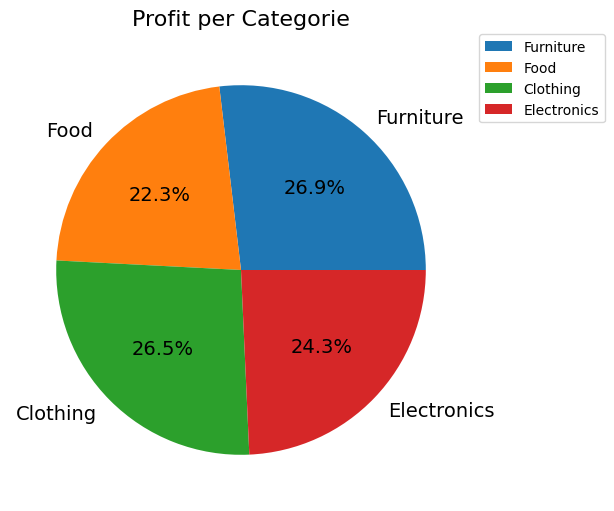

In [49]:
profits = []
labels = []
for label,profit in category_profit.items():
  labels.append(label)
  profits.append(profit)

y = np.array(profits)

plt.figure(figsize=(6,6))

plt.pie(y, labels=labels, autopct='%1.1f%%', textprops={'fontsize':14})

plt.title(label="Profit per Categorie", fontdict={"fontsize":16}, pad=10)

plt.legend(bbox_to_anchor=(1,1.025), loc="upper left")

plt.show()